# Average Shortest Paths Simple Trading Strategy

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

**Strategy**
- When the positive average shortest paths is higher than the negative average shortest paths buy/hold. Otherwise sell.
- Will start with $1000 for each stock.
- Buying will use up all capital for that stock and selling will sell all units of a stock.

In [ ]:
NUM_COL = 'prc'
DATE_COL = 'date'
TICKER_COL = 'permno'
START_BALANCE = 1000
EXIT_PROP = 1.0
LOOKBACK=7

In [50]:
asvp = pd.read_csv('./data/all_asvp_crsp_window_7.csv')
asvp[DATE_COL] = pd.to_datetime(asvp[DATE_COL])
asvp.head()

,date,permno,pos,neg,prc
0,2010-01-13,10002,1.476190,1.714286,2.82
1,2010-01-14,10002,1.476190,1.619048,2.85
2,2010-01-15,10002,1.333333,1.809524,2.89
3,2010-01-19,10002,1.333333,1.571429,2.74
4,2010-01-20,10002,1.476190,1.476190,2.85


##### Initial Exploration

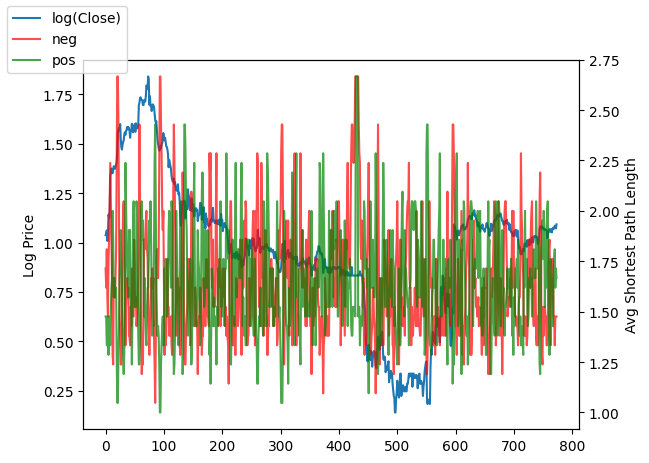

In [84]:
ticker = 10002
df = asvp[asvp[TICKER_COL] == ticker]

fig, ax1 = plt.subplots()

ax1.plot(np.log(df[NUM_COL]), label="log(Close)")
ax1.set_ylabel("Log Price")

ax2 = ax1.twinx()
ax2.plot(df["neg"], color="red", label="neg", alpha=0.7)
ax2.plot(df["pos"], color="green", label="pos", alpha=0.7)
ax2.set_ylabel("Avg Shortest Path Length")

fig.legend(loc="upper left")
plt.show()

In [98]:
curr_b = START_BALANCE
curr_vol = 0
### Full Exit
exit_prop = EXIT_PROP
returns = []

for _, row in df.iterrows():

    pos = row['pos']
    neg = row['neg']
    num = row[NUM_COL]

    # Buy signal
    if pos >= neg:
        ### Only buy if we have balance
        ### Otherwise we will just be holding the stock
        if curr_b > 0:
            curr_vol += curr_b / num
            curr_b = 0

    # Sell signal
    else:
        ### Only sell if we have volume to sell
        if curr_vol > 0:
            shares_sold = exit_prop * curr_vol
            curr_b += shares_sold * num
            curr_vol -= shares_sold
            
    ### Current Return of the Strategy
    ### Cash Balance + Value of Held Stock
    returns.append(curr_b + curr_vol * num)

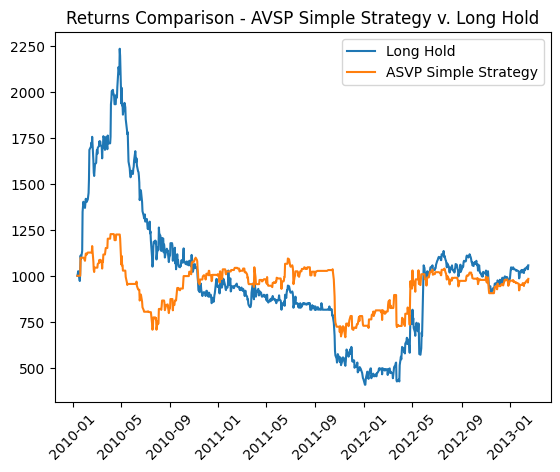

In [123]:
start_vol = START_BALANCE / df[NUM_COL].iloc[0]

hold_ret = start_vol * df[NUM_COL].values

sns.lineplot(x=df[DATE_COL].values, y=hold_ret, label="Long Hold")
sns.lineplot(x=df[DATE_COL].values, y=returns, label="ASVP Simple Strategy")

plt.title("Returns Comparison - AVSP Simple Strategy v. Long Hold")
plt.xticks(rotation=45)
plt.legend()
plt.show()

##### Function Development

In [ ]:
def asvp_simple_strat_single(df, curr_b=1000, exit_prop=1.0):
    ### Defaults to starting balance of 1000 and full exits
    curr_vol = 0

    returns = []

    for _, row in df.iterrows():

        pos = row['pos']
        neg = row['neg']
        num = row[NUM_COL]

        ### Buy signal
        if pos >= neg:
            ### Only buy if we have balance
            ### Otherwise we will just be holding the stock
            if curr_b > 0:
                curr_vol += curr_b / num
                curr_b = 0

        ### Sell signal
        else:
            ### Only sell if we have volume to sell
            if curr_vol > 0:
                shares_sold = exit_prop * curr_vol
                curr_b += shares_sold * num
                curr_vol -= shares_sold
                
        ### Current Return of the Strategy
        ### Cash Balance + Value of Held Stock
        returns.append(curr_b + curr_vol * num)
    
    return returns

In [102]:
def asvp_simple_strat(data, tickers, curr_b=START_BALANCE, exit_prop=EXIT_PROP):
    ret_df = pd.DataFrame()
    for t in tickers:
        df = data[data[TICKER_COL] == t].reset_index(drop=True)
        returns = asvp_simple_strat_single(df, curr_b=curr_b, exit_prop=exit_prop)
        start_vol = START_BALANCE / df[NUM_COL].iloc[0]
        hold_ret = start_vol * df[NUM_COL].values
        stg_df = (
            df[[TICKER_COL, DATE_COL]]
            .copy()
            .assign(
                strat_ret=returns,
                hold_ret=hold_ret
            )
        )
        if len(ret_df) == 0:
            ret_df = stg_df.copy()
        else:
            ret_df = pd.concat([ret_df, stg_df])
    
    return ret_df

In [ ]:
data = asvp.copy()
tickers = data[TICKER_COL].unique()
ret_df = asvp_simple_strat(data, tickers)
ret_df.to_csv(f"./data/all_asvp_simple_rets_window_{LOOKBACK}.csv", index=False)

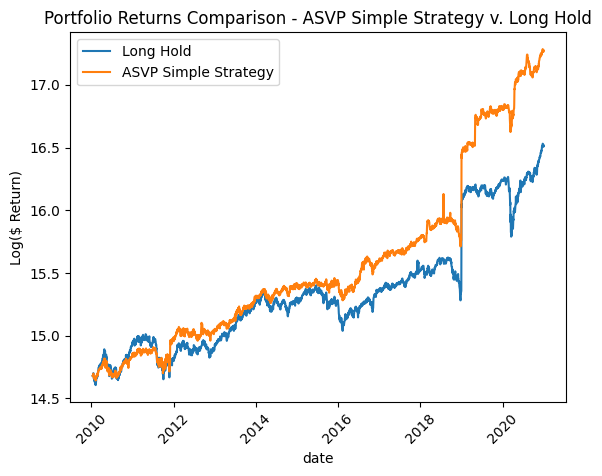

In [122]:
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum"})

sns.lineplot(x=plot_df.index, y=np.log(plot_df['hold_ret']), label="Long Hold")
sns.lineplot(x=plot_df.index, y=np.log(plot_df['strat_ret']), label="ASVP Simple Strategy")

plt.title("Portfolio Returns Comparison - ASVP Simple Strategy v. Long Hold")
plt.ylabel("Log($ Return)")
plt.xticks(rotation=45)
plt.legend()
plt.show()

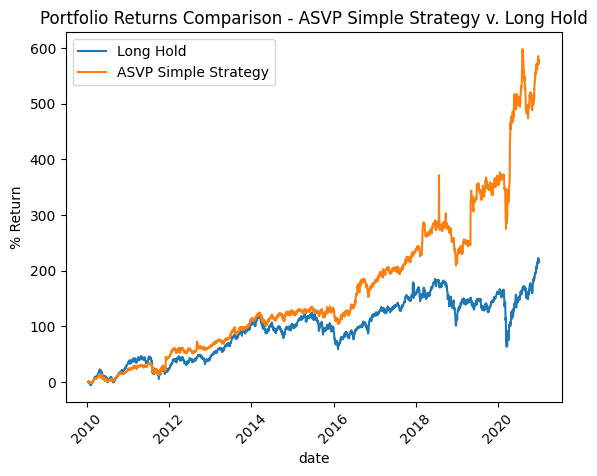

In [121]:
plot_df = ret_df.groupby(by=DATE_COL).agg({"strat_ret" : "sum", "hold_ret" : "sum", TICKER_COL : "count"}).rename(columns={TICKER_COL:"num_stocks"})
plot_df['base_bal'] = plot_df["num_stocks"] * START_BALANCE
plot_df["strat_pct_grwth"] = (plot_df["strat_ret"] / plot_df['base_bal'] - 1) * 100
plot_df["hold_pct_grwth"] = (plot_df["hold_ret"] / plot_df['base_bal'] - 1) * 100

sns.lineplot(x=plot_df.index, y=plot_df['hold_pct_grwth'], label="Long Hold")
sns.lineplot(x=plot_df.index, y=plot_df['strat_pct_grwth'], label="ASVP Simple Strategy")

plt.title("Portfolio Returns Comparison - ASVP Simple Strategy v. Long Hold")
plt.ylabel("% Return")
plt.xticks(rotation=45)
plt.legend()
plt.show()